<a href="https://colab.research.google.com/github/Shorovpaul/Performance-and-Explainability-Behavior-of-Ensemble-Machine-Learning-Models-on-Healthcare-01-/blob/main/Cleaned_dataset_Thyroid1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1. Install Libraries***

In [ ]:
pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

## ***2. Load Dataset***

In [ ]:
import pandas as pd

data = pd.read_csv("cleaned_dataset_Thyroid1.csv")

print(data.shape)

data.rename(columns={'binaryClass': 'Class'}, inplace=True)


print(data.columns.tolist())


print(data['Class'].value_counts())

(3771, 26)
['age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'Class']
Class
0    3480
1     291
Name: count, dtype: int64


# ***3. Train / Test Split***

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ***4. Handle Imbalance***

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(y_train_bal.value_counts())

Class
0    2783
1    2783
Name: count, dtype: int64


## ***5. Scaling***

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# ***6. Train Candidate Models***

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

# ***7. Performance Screening***

In [ ]:
from sklearn.metrics import average_precision_score

model_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:,1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

print(model_scores)

{'LR': np.float64(0.8912570344497875), 'RF': np.float64(0.9978480967314165), 'GB': np.float64(0.9510227225652094), 'KNN': np.float64(0.34030869599383917), 'SVM': np.float64(0.7403698169597202), 'XGB': np.float64(0.9731035677918211)}


**Remove weak models.**

In [ ]:
selected_models = {
    name:model for name,model in trained_models.items()
    if model_scores[name] > 0.70
}

# ***8. Generate SHAP Explanations***

In [ ]:
import shap
import numpy as np

explanations = {}

for name, model in selected_models.items():
    if name == "SVM":

        explainer = shap.Explainer(model.predict_proba, X_train_bal[:1000])
        shap_values = explainer(X_train_bal[:1000])

        importance = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
    else:
        explainer = shap.Explainer(model, X_train_bal[:1000])
        shap_values = explainer(X_train_bal[:1000])


        if shap_values.values.ndim == 3:

            importance = np.abs(shap_values.values[:, :, 1]).mean(axis=0)
        else:
            importance = np.abs(shap_values.values).mean(axis=0)

    explanations[name] = importance

 98%|===================| 1965/2000 [00:17<00:00]       WARNING:shap:Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.
PermutationExplainer explainer: 1001it [37:25,  2.25s/it]


## ***9. Explanation Stability***

In [ ]:
import shap
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

stability_scores = {}

# For reproducibility, use a fixed random seed
np.random.seed(42)

for name, model in selected_models.items():
    # Take a random sample of 1000 instances from X_train_bal for stability check
    # Ensure replace=False if X_train_bal has enough samples
    sample_indices = np.random.choice(X_train_bal.shape[0], 1000, replace=False)
    X_stability_subset = X_train_bal[sample_indices]

    if name == "SVM":
        explainer = shap.Explainer(model.predict_proba, X_stability_subset)
        shap_values_stability = explainer(X_stability_subset)
        importance_stability = np.abs(shap_values_stability.values[:, :, 1]).mean(axis=0)
    else:
        explainer = shap.Explainer(model, X_stability_subset)
        shap_values_stability = explainer(X_stability_subset)
        if shap_values_stability.values.ndim == 3:
            importance_stability = np.abs(shap_values_stability.values[:, :, 1]).mean(axis=0)
        else:
            importance_stability = np.abs(shap_values_stability.values).mean(axis=0)

    # Compare with original explanation stored in the 'explanations' dictionary
    original_importance = explanations[name]

    # Calculate cosine similarity between the original and new explanations
    sim = cosine_similarity(original_importance.reshape(1, -1), importance_stability.reshape(1, -1))[0][0]
    stability_scores[name] = sim

print(stability_scores)

 98%|===================| 1958/2000 [00:29<00:00]       WARNING:shap:Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.
PermutationExplainer explainer: 1001it [42:20,  2.55s/it]


{'LR': np.float64(0.7606591971242229), 'RF': np.float64(0.9915017269242649), 'GB': np.float64(0.9999657194210374), 'SVM': np.float64(0.9151678500711751), 'XGB': np.float64(0.9899480199536298)}


# ***10. Explanation Diversity***

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

diversity_scores = {}

names = list(explanations.keys())

for i in range(len(names)):
    for j in range(i+1, len(names)):

        sim = cosine_similarity(
            explanations[names[i]].reshape(1,-1),
            explanations[names[j]].reshape(1,-1)
        )[0][0]

        diversity = 1 - sim

        diversity_scores[(names[i],names[j])] = diversity

print(diversity_scores)

{('LR', 'RF'): np.float64(0.24470811362793077), ('LR', 'GB'): np.float64(0.547844257783114), ('LR', 'SVM'): np.float64(0.16183091099916858), ('LR', 'XGB'): np.float64(0.2569033040234775), ('RF', 'GB'): np.float64(0.298220258637935), ('RF', 'SVM'): np.float64(0.35314433591730676), ('RF', 'XGB'): np.float64(0.013236389375779423), ('GB', 'SVM'): np.float64(0.5536340552690973), ('GB', 'XGB'): np.float64(0.2652309736121441), ('SVM', 'XGB'): np.float64(0.3280335267182609)}


In [ ]:
final_scores = {}

for name in selected_models:

    performance = model_scores[name]
    stability = stability_scores[name]

    diversity = np.mean([
        v for k,v in diversity_scores.items() if name in k
    ])

    score = (
        0.5 * performance +
        0.3 * stability +
        0.2 * diversity
    )

    final_scores[name] = score

print(final_scores)

{'LR': np.float64(0.7343906056838452), 'RF': np.float64(0.8418400213209354), 'GB': np.float64(0.8587475543740304), 'SVM': np.float64(0.7145674049464042), 'XGB': np.float64(0.8267063995684826)}


In [ ]:
top_models = sorted(final_scores, key=final_scores.get, reverse=True)[:3]

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [(name, selected_models[name]) for name in top_models]

meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

stack.fit(X_train_bal, y_train_bal)

StackingClassifier(estimators=[('GB', GradientBoostingClassifier()),
                               ('RF', RandomForestClassifier(n_estimators=200)),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=Non...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())

In [ ]:
probs = stack.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import average_precision_score

auprc = average_precision_score(y_test, probs)

print("Stacked AUPRC:", auprc)

Stacked AUPRC: 0.9913742839826576


PermutationExplainer explainer: 201it [01:32,  1.86it/s]
/tmp/ipykernel_3456/2910947139.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values)


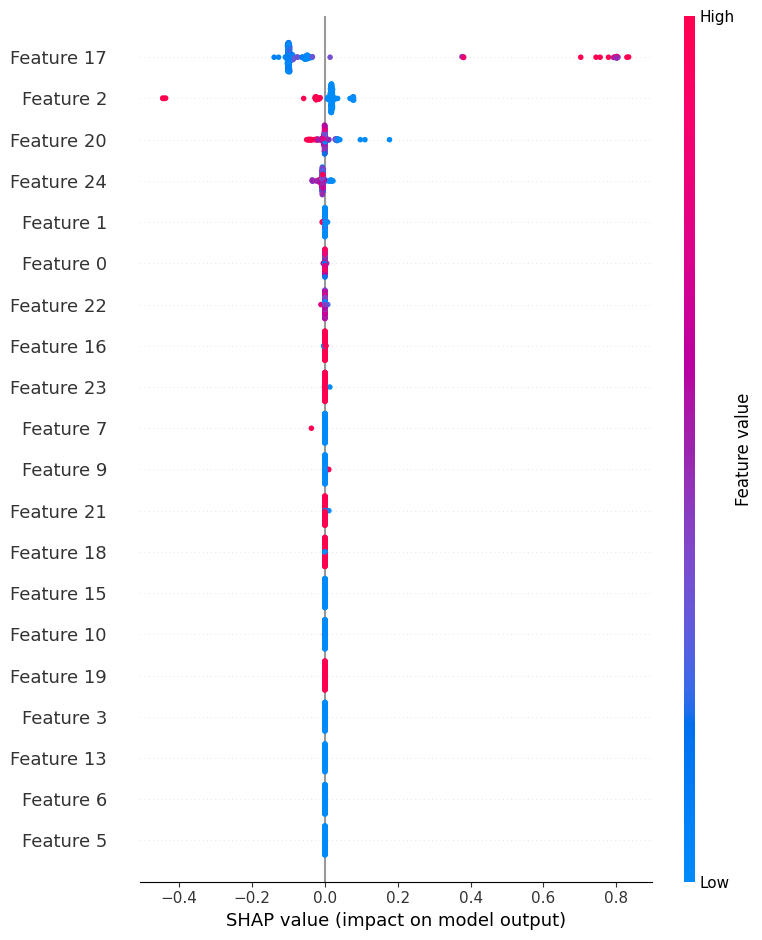

In [ ]:
explainer = shap.Explainer(lambda x: stack.predict_proba(x)[:, 1], X_train_bal[:1000])
shap_values = explainer(X_test_scaled[:200])

shap.summary_plot(shap_values)

--- Evaluation Metrics ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       697
           1       1.00      0.95      0.97        58

    accuracy                           1.00       755
   macro avg       1.00      0.97      0.99       755
weighted avg       1.00      1.00      1.00       755



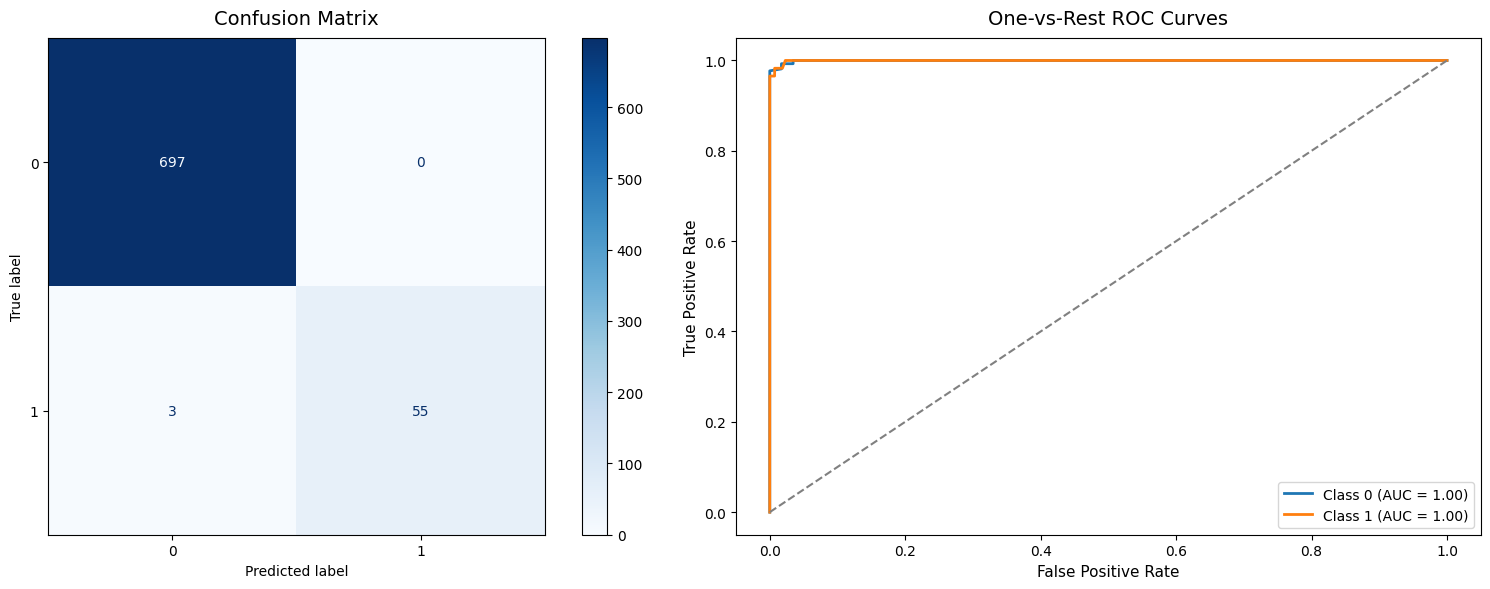


--- Computing SHAP Values ---


/tmp/ipykernel_3456/2816393205.py:83: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


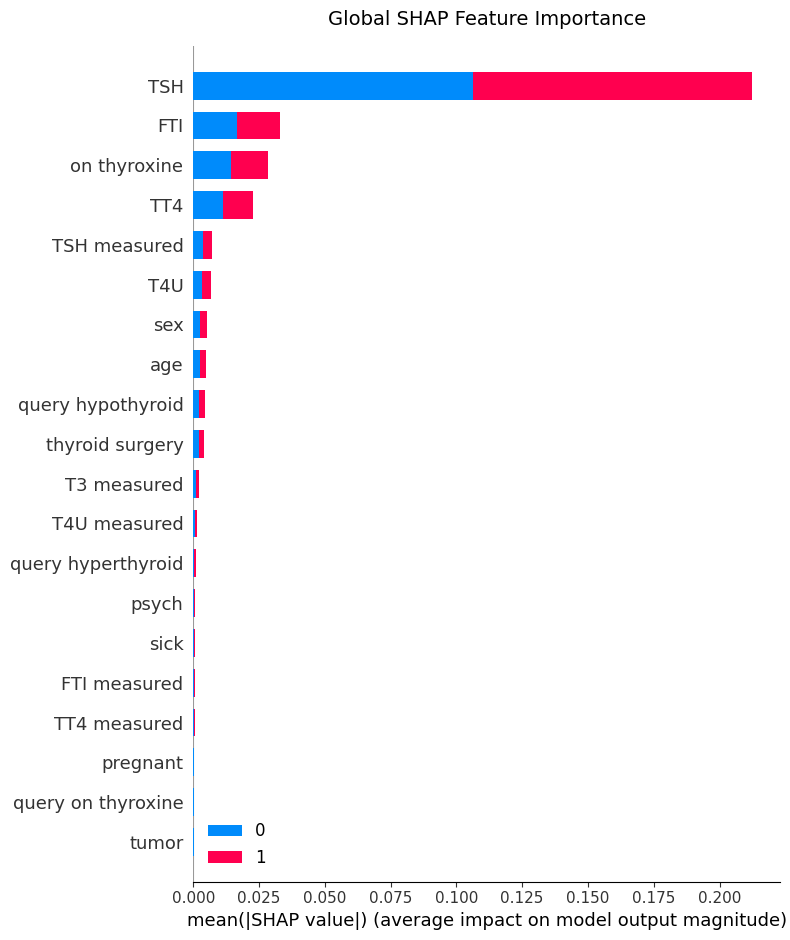

/tmp/ipykernel_3456/2816393205.py:106: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(target_shap_values, X_test, show=False)


AttributeError: 'numpy.int64' object has no attribute 'upper'

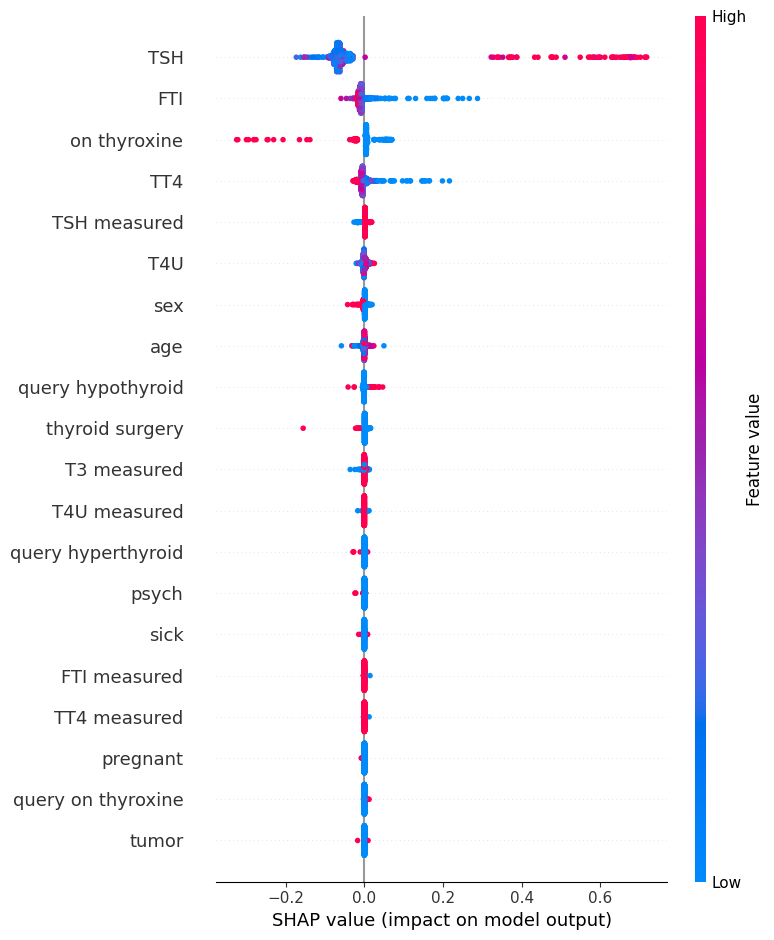

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Isolate Features and Target from your preprocessed DataFrame
X = data.drop(columns=["Class"])
y = data["Class"]

# Encode target strings ('negative', 'hypothyroid', 'hyperthyroid') to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Stratified split to preserve class distributions
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded
)

# 2. Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict classes and probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Print Performance Report
print("--- Evaluation Metrics ---")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

# =========================================================
# EVALUATION VISUALIZATIONS
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_.astype(str))
disp.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Confusion Matrix", fontsize=14, pad=10)
axes[0].grid(False)

# Right Plot: Multiclass One-vs-Rest ROC Curve
for i, class_name in enumerate(le.classes_):
    # Binary labels for the current class
    y_test_bi = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bi, y_prob[:, i])
    auc_score = roc_auc_score(y_test_bi, y_prob[:, i])
    axes[1].plot(
        fpr, tpr, lw=2, label=f"Class {class_name} (AUC = {auc_score:.2f})"
    )

axes[1].plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title("One-vs-Rest ROC Curves", fontsize=14, pad=10)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# =========================================================
# SHAP EXPLAINABILITY VISUALIZATIONS
# =========================================================
print("\n--- Computing SHAP Values ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For scikit-learn 1.6+ and shap modern versions, TreeExplainer outputs an array
# of shape (n_samples, n_features, n_classes). Let's resolve the multi-class layout.

# Plot 1: Overall Summary Bar Plot (Global across all classes)
plt.figure(figsize=(10, 5))
shap.summary_plot(
    list(shap_values.transpose(2, 0, 1))
    if shap_values.ndim == 3
    else shap_values,
    X_test,
    class_names=le.classes_.astype(str),
    plot_type="bar",
    show=False,
)
plt.title("Global SHAP Feature Importance", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Plot 2: Directional Beeswarm Plot for a Specific Class
# Let's map it for 'hypothyroid' (usually class index 1)
class_idx_to_plot = 1
class_label = le.classes_[class_idx_to_plot]

plt.figure(figsize=(10, 6))
# Isolate the matrix for the chosen class index
target_shap_values = (
    shap_values[:, :, class_idx_to_plot] if shap_values.ndim == 3 else shap_values[class_idx_to_plot]
)
shap.summary_plot(target_shap_values, X_test, show=False)
plt.title(f"SHAP Beeswarm Plot - Impact Direction for: {class_label.upper()}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()